# Inference Latency Comparison (Dynamic DeepHit Models)

This notebook benchmarks forward-pass inference latency for four model families:
- GRU
- GRU + Transformer
- Transformer
- Mamba

It reports mean/std/p50/p90 latency and throughput across batch sizes.

In [1]:
from __future__ import annotations

import math
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

SEED = 4718
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

Device: cuda
GPU: Tesla V100-SXM2-32GB


In [2]:
# Verify install status only. Use Cell 3 for installation/retry logic.
import os
import sys

from src.notebook_setup import module_exists

BASE_CACHE = (
    os.environ.get("SCRATCH")
    or os.environ.get("LOCAL_SCRATCH")
    or "/ocean/projects/cis260122p/ccheung1/.cache/lob-dsa"
)
PKG_DIR = os.path.join(BASE_CACHE, ".py-packages")
if PKG_DIR not in sys.path:
    sys.path.insert(0, PKG_DIR)

have_causal = module_exists("causal_conv1d")
have_mamba = module_exists("mamba_ssm")

print("Package dir:", PKG_DIR)
print("Python:", sys.executable)
print("causal_conv1d installed:", have_causal)
print("mamba_ssm installed:", have_mamba)
import causal_conv1d
import mamba_ssm

# Always reload model modules after dependency setup so Mamba import state is fresh.
for mod_name in list(sys.modules):
    if mod_name == "src.models" or mod_name.startswith("src.models."):
        del sys.modules[mod_name]

from src.models import (
    DeepHitMambaCompeting,
    DeepHitRNNCompeting,
    DeepHitRNNTransformerCompeting,
    DeepHitTransformerCompeting,
)

print("Model modules loaded/reloaded successfully.")

Package dir: /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.py-packages
Python: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob/bin/python3.11
causal_conv1d installed: True
mamba_ssm installed: True
Model modules loaded/reloaded successfully.


In [3]:
NUM_FEATURES = 34
NUM_EVENTS = 2
NUM_TIME_STEPS = 30
SEQ_LEN = 500
DTYPE = torch.float32

BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64]
WARMUP_ITERS = 20
MEASURE_ITERS = 80
USE_AMP = device.type == "cuda"
AMP_DTYPE = torch.float16

@dataclass
class ModelSpec:
    name: str
    builder: callable

# Tuned final model configuration
MODEL_SPECS_TUNED = [
    ModelSpec(
        "gru",
        lambda: DeepHitRNNCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=160,
            num_layers=1,
            rnn_dropout=0.2,
            fc_hidden=int(160 * 1.75),
            fc_dropout=0.2,
        ),
    ),
    ModelSpec(
        "gru_transformer",
        lambda: DeepHitRNNTransformerCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=96,
            num_layers=1,
            rnn_dropout=0.2,
            transformer_layers=1,
            transformer_heads=2,
            transformer_ff_dim=int(96 * 3.0),
            transformer_dropout=0.1,
            max_seq_len=SEQ_LEN,
            fc_hidden=int(96 * 1.75),
            fc_dropout=0.2,
        ),
    ),
    ModelSpec(
        "transformer",
        lambda: DeepHitTransformerCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=96,
            num_layers=4,
            num_heads=4,
            transformer_ff_dim=int(96 * 3.0),
            transformer_dropout=0.1,
            max_seq_len=SEQ_LEN,
            fc_hidden=int(96 * 1.75),
            fc_dropout=0.2,
        ),
    ),
    ModelSpec(
        "mamba",
        lambda: DeepHitMambaCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=96,
            num_mamba_layers=2,
            d_state=8,
            d_conv=4,
            expand=4,
            mamba_dropout=0.15,
            fc_hidden=int(96 * 1.75),
            fc_dropout=0.2,
        ),
    ),
]

# Size-matched configuration (~300-350k parameters per model)
MODEL_SPECS_SIZE_MATCHED = [
    ModelSpec(
        "gru",
        lambda: DeepHitRNNCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=144,
            num_layers=2,
            rnn_dropout=0.2,
            fc_hidden=256,
            fc_dropout=0.2,
        ),
    ),
    ModelSpec(
        "gru_transformer",
        lambda: DeepHitRNNTransformerCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=96,
            num_layers=2,
            rnn_dropout=0.2,
            transformer_layers=2,
            transformer_heads=4,
            transformer_ff_dim=192,
            transformer_dropout=0.1,
            max_seq_len=SEQ_LEN,
            fc_hidden=128,
            fc_dropout=0.2,
        ),
    ),
    ModelSpec(
        "transformer",
        lambda: DeepHitTransformerCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=96,
            num_layers=2,
            num_heads=4,
            transformer_ff_dim=320,
            transformer_dropout=0.1,
            max_seq_len=SEQ_LEN,
            fc_hidden=112,
            fc_dropout=0.2,
        ),
    ),
    ModelSpec(
        "mamba",
        lambda: DeepHitMambaCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=128,
            num_mamba_layers=2,
            d_state=16,
            d_conv=4,
            expand=2,
            mamba_dropout=0.15,
            fc_dropout=0.2,
        ),
    ),
]

ALL_CONFIGS = [
    ("tuned", MODEL_SPECS_TUNED),
    ("size_matched", MODEL_SPECS_SIZE_MATCHED),
]

In [4]:
def _sync_if_needed() -> None:
    if device.type == "cuda":
        torch.cuda.synchronize()


def benchmark_forward_latency_ms(model: torch.nn.Module, x: torch.Tensor, warmup: int, iters: int) -> list[float]:
    model.eval()
    times_ms: list[float] = []

    with torch.inference_mode():
        for _ in range(warmup):
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                _ = model(x)

        _sync_if_needed()

        if device.type == "cuda":
            starter = torch.cuda.Event(enable_timing=True)
            ender = torch.cuda.Event(enable_timing=True)

            for _ in range(iters):
                starter.record()
                with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                    _ = model(x)
                ender.record()
                torch.cuda.synchronize()
                times_ms.append(starter.elapsed_time(ender))
        else:
            for _ in range(iters):
                t0 = time.perf_counter()
                _ = model(x)
                t1 = time.perf_counter()
                times_ms.append((t1 - t0) * 1000.0)

    return times_ms


def summarize_times(model_name: str, batch_size: int, times_ms: list[float], n_params: int) -> dict:
    p50 = float(np.percentile(times_ms, 50))
    p90 = float(np.percentile(times_ms, 90))
    mean_ms = float(np.mean(times_ms))
    std_ms = float(np.std(times_ms))
    throughput = float(batch_size * 1000.0 / mean_ms) if mean_ms > 0 else math.nan
    return {
        "model": model_name,
        "batch_size": batch_size,
        "n_params": int(n_params),
        "latency_mean_ms": mean_ms,
        "latency_std_ms": std_ms,
        "latency_p50_ms": p50,
        "latency_p90_ms": p90,
        "throughput_samples_per_s": throughput,
        "num_measurements": len(times_ms),
    }

In [5]:
results = []

for config_name, model_specs in ALL_CONFIGS:
    print(f"\n{'=' * 60}")
    print(f"Config: {config_name}")
    print(f"{'=' * 60}", flush=True)

    for spec in model_specs:
        print(f"\n=== Benchmarking {spec.name} ===", flush=True)

        try:
            model = spec.builder().to(device)
        except Exception as exc:
            print(f"Skipping {spec.name}: model build failed -> {exc}", flush=True)
            continue

        n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        for bs in BATCH_SIZES:
            x = torch.randn(bs, SEQ_LEN, NUM_FEATURES, dtype=DTYPE, device=device)

            try:
                times = benchmark_forward_latency_ms(
                    model=model,
                    x=x,
                    warmup=WARMUP_ITERS,
                    iters=MEASURE_ITERS,
                )
                row = summarize_times(spec.name, bs, times, n_params)
                row["config"] = config_name
                results.append(row)
                print(
                    f"{spec.name:>16} | bs={bs:>4} | mean={row['latency_mean_ms']:.3f} ms | p90={row['latency_p90_ms']:.3f} ms | "
                    f"throughput={row['throughput_samples_per_s']:.1f} samples/s",
                    flush=True,
                )
            except RuntimeError as exc:
                if "out of memory" in str(exc).lower() or "cuda oom" in str(exc).lower():
                    print(f"{spec.name:>16} | bs={bs:>4} | OOM -> skipping larger measurements for this batch", flush=True)
                    if device.type == "cuda":
                        torch.cuda.empty_cache()
                else:
                    print(f"{spec.name:>16} | bs={bs:>4} | failed -> {exc}", flush=True)

        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values(["config", "batch_size", "latency_mean_ms"]).reset_index(drop=True)

results_df


Config: tuned

=== Benchmarking gru ===
             gru | bs=   1 | mean=2.424 ms | p90=2.521 ms | throughput=412.6 samples/s
             gru | bs=   2 | mean=2.345 ms | p90=2.436 ms | throughput=852.9 samples/s
             gru | bs=   4 | mean=2.326 ms | p90=2.347 ms | throughput=1719.7 samples/s
             gru | bs=   8 | mean=2.035 ms | p90=2.044 ms | throughput=3931.2 samples/s
             gru | bs=  16 | mean=2.142 ms | p90=2.147 ms | throughput=7471.0 samples/s
             gru | bs=  32 | mean=2.315 ms | p90=2.321 ms | throughput=13824.5 samples/s
             gru | bs=  64 | mean=2.604 ms | p90=2.617 ms | throughput=24580.0 samples/s

=== Benchmarking gru_transformer ===
 gru_transformer | bs=   1 | mean=2.048 ms | p90=2.065 ms | throughput=488.2 samples/s
 gru_transformer | bs=   2 | mean=2.137 ms | p90=2.135 ms | throughput=935.8 samples/s
 gru_transformer | bs=   4 | mean=2.134 ms | p90=2.144 ms | throughput=1874.6 samples/s
 gru_transformer | bs=   8 | mean=2.768 ms 

,model,batch_size,n_params,latency_mean_ms,latency_std_ms,latency_p50_ms,latency_p90_ms,throughput_samples_per_s,num_measurements,config
0,mamba,1,341085,1.821914,0.016584,1.817600,1.845555,548.873449,80,size_matched
1,transformer,1,304669,2.065907,0.142447,2.040320,2.089984,484.048845,80,size_matched
2,gru_transformer,1,349917,3.036928,0.022395,3.030528,3.056435,329.280119,80,size_matched
3,gru,1,345597,3.720102,0.015900,3.715584,3.733606,268.809806,80,size_matched
4,mamba,2,341085,1.817024,0.012185,1.816064,1.821696,1100.700928,80,size_matched
5,transformer,2,304669,2.110899,0.023515,2.102272,2.142311,947.463515,80,size_matched
6,gru_transformer,2,349917,3.150963,0.033126,3.137536,3.184640,634.726548,80,size_matched
7,gru,2,345597,3.853978,0.026493,3.850240,3.886285,518.944376,80,size_matched
8,mamba,4,341085,1.814490,0.015269,1.811456,1.817600,2204.476691,80,size_matched
9,transformer,4,304669,2.104768,0.026531,2.095104,2.143642,1900.447002,80,size_matched



Config: tuned
config           model  batch_size  n_params  latency_mean_ms  latency_p50_ms  latency_p90_ms  throughput_samples_per_s
 tuned           mamba           1    326061         1.843072        1.838592        1.866547                542.572400
 tuned gru_transformer           1    248109         2.048166        2.042880        2.065203                488.241574
 tuned             gru           1    264973         2.423718        2.466304        2.521190                412.589252
 tuned     transformer           1    493389         3.028416        3.008512        3.090739                330.205626
 tuned           mamba           2    326061         1.835123        1.828864        1.858867               1089.845086
 tuned gru_transformer           2    248109         2.137126        2.103296        2.134630                935.836082
 tuned             gru           2    264973         2.344819        2.308096        2.436096                852.944225
 tuned     transformer   

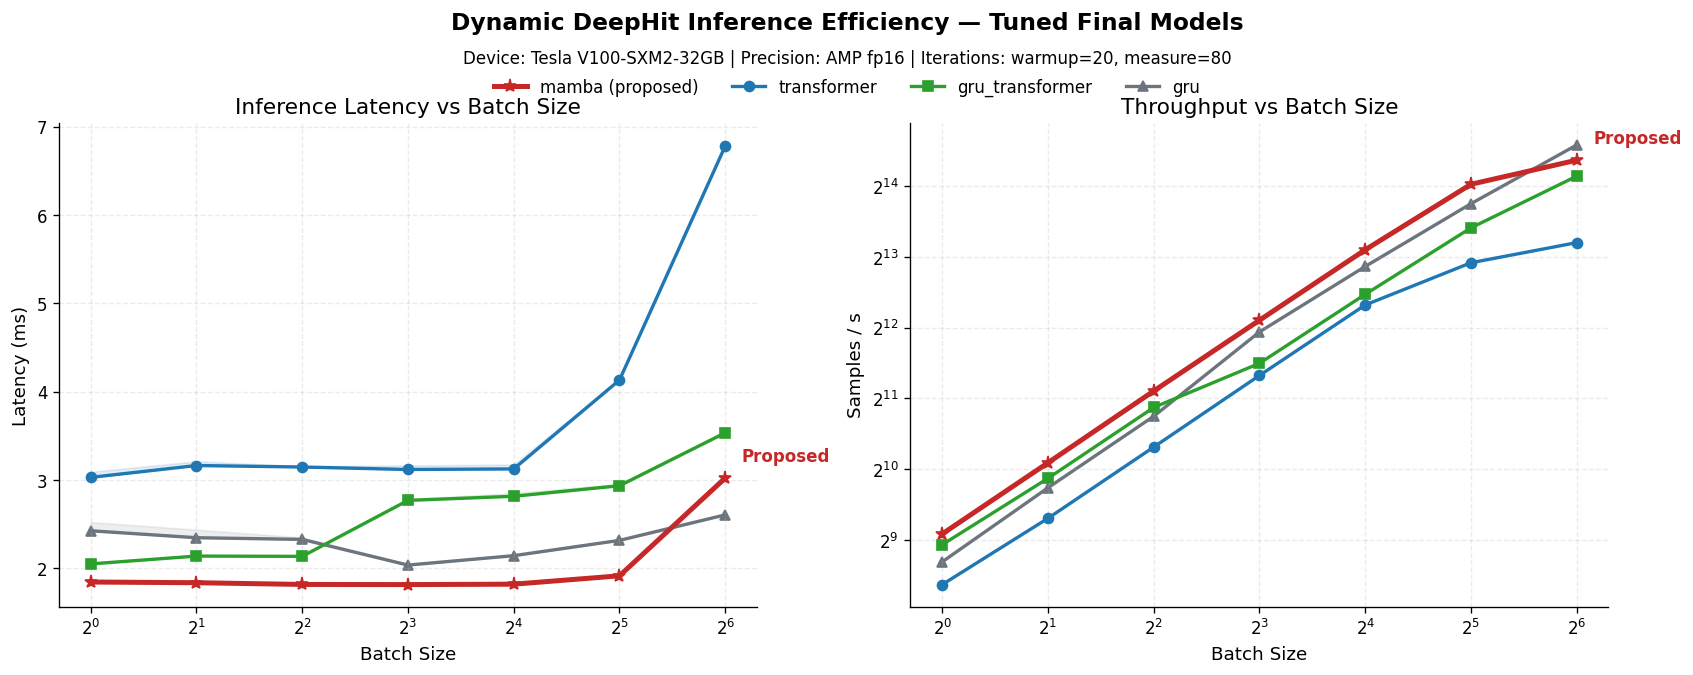

Saved figures to results/figures/latency_tuned.png and results/figures/latency_tuned.pdf


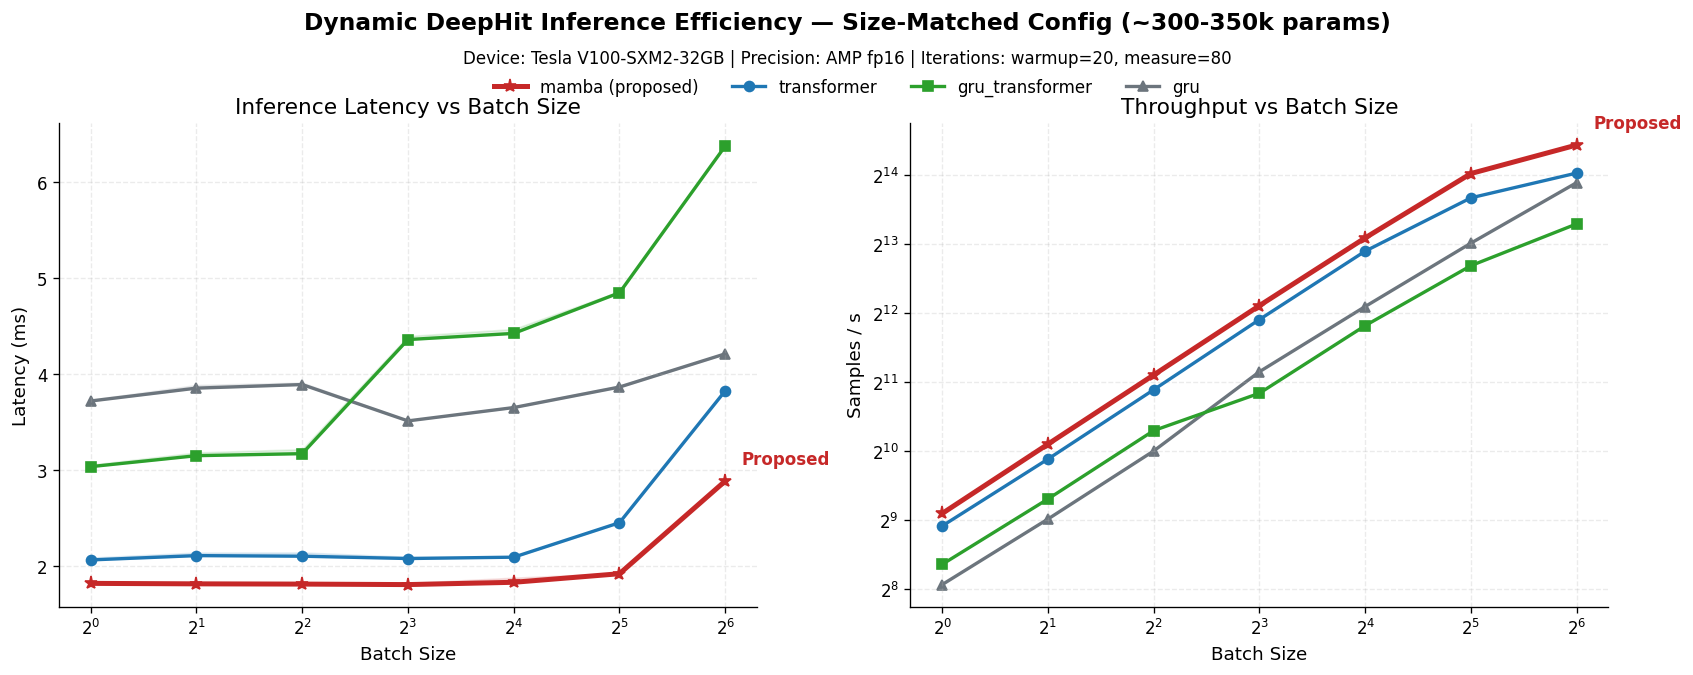

Saved figures to results/figures/latency_size_matched.png and results/figures/latency_size_matched.pdf


In [6]:
if results_df.empty:
    raise RuntimeError("No benchmark results were collected.")

display_cols = [
    "config",
    "model",
    "batch_size",
    "n_params",
    "latency_mean_ms",
    "latency_p50_ms",
    "latency_p90_ms",
    "throughput_samples_per_s",
]

for config_name, _ in ALL_CONFIGS:
    cfg_df = results_df[results_df["config"] == config_name]
    if cfg_df.empty:
        continue
    print(f"\n{'=' * 90}")
    print(f"Config: {config_name}")
    print("=" * 90)
    print(cfg_df[display_cols].to_string(index=False))

# Paper-ready benchmark metadata
import platform
from datetime import datetime, timezone
from pathlib import Path

param_by_model = (
    results_df[["config", "model", "n_params"]]
    .drop_duplicates(subset=["config", "model"])
    .assign(key=lambda df: df["config"] + "/" + df["model"])
    .set_index("key")["n_params"]
    .to_dict()
)

reported_models = sorted(results_df["model"].unique().tolist())

paper_metadata = {
    "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%SZ"),
    "host_platform": platform.platform(),
    "python_version": platform.python_version(),
    "pytorch_version": torch.__version__,
    "device_type": device.type,
    "gpu_name": torch.cuda.get_device_name(0) if device.type == "cuda" else "N/A",
    "cuda_runtime": torch.version.cuda if torch.version.cuda is not None else "N/A",
    "cudnn_version": int(torch.backends.cudnn.version()) if torch.backends.cudnn.version() is not None else "N/A",
    "cudnn_benchmark": bool(torch.backends.cudnn.benchmark),
    "seed": int(SEED),
    "input_shape_template": f"(batch, {SEQ_LEN}, {NUM_FEATURES})",
    "num_events": int(NUM_EVENTS),
    "num_time_steps": int(NUM_TIME_STEPS),
    "input_dtype": str(DTYPE),
    "amp_enabled": bool(USE_AMP),
    "amp_dtype": str(AMP_DTYPE),
    "warmup_iterations": int(WARMUP_ITERS),
    "measured_iterations": int(MEASURE_ITERS),
    "batch_sizes": [int(b) for b in BATCH_SIZES],
    "timing_method": "CUDA events + synchronize" if device.type == "cuda" else "time.perf_counter",
    "inference_mode": True,
    "configs_benchmarked": [name for name, _ in ALL_CONFIGS],
    "models_benchmarked": reported_models,
    "model_parameters": {k: int(v) for k, v in param_by_model.items()},
}

print("\n" + "=" * 90)
print("PAPER REPORTING METADATA (copy into Methods / Experimental Setup)")
print("=" * 90)
for key, value in paper_metadata.items():
    print(f"{key:<25}: {value}")
print("=" * 90)

if "have_mamba" in globals() and "have_causal" in globals():
    print(f"Dependency status -> causal_conv1d={have_causal}, mamba_ssm={have_mamba}")

plt.rcParams.update(
    {
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    }
)

color_map = {
    "mamba": "#C62828",
    "transformer": "#1F77B4",
    "gru_transformer": "#2CA02C",
    "gru": "#6C757D",
}

marker_map = {
    "mamba": "*",
    "transformer": "o",
    "gru_transformer": "s",
    "gru": "^",
}

line_width_map = {
    "mamba": 3.0,
    "transformer": 2.0,
    "gru_transformer": 2.0,
    "gru": 2.0,
}

zorder_map = {
    "mamba": 5,
    "transformer": 3,
    "gru_transformer": 2,
    "gru": 1,
}

plot_model_order = ["mamba", "transformer", "gru_transformer", "gru"]
config_titles = {"tuned": "Tuned Final Models", "size_matched": "Size-Matched Config (~300-350k params)"}

fig_dir = Path("results") / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

out_csv = "results/latency_comparison.csv"
results_df.to_csv(out_csv, index=False)
print(f"Saved benchmark table to {out_csv}")

for config_name, _ in ALL_CONFIGS:
    cfg_df = results_df[results_df["config"] == config_name]
    if cfg_df.empty:
        continue

    models_in_cfg = cfg_df["model"].unique()
    ordered_models = [m for m in plot_model_order if m in models_in_cfg]
    ordered_models += sorted([m for m in models_in_cfg if m not in plot_model_order])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
    ax_lat, ax_thr = axes

    for model_name in ordered_models:
        grp = cfg_df[cfg_df["model"] == model_name].sort_values("batch_size")
        color = color_map.get(model_name, "#444444")
        marker = marker_map.get(model_name, "o")
        lw = line_width_map.get(model_name, 2.0)
        zo = zorder_map.get(model_name, 1)

        mean_latency = grp["latency_mean_ms"].to_numpy()
        p90_latency = grp["latency_p90_ms"].to_numpy()
        throughput = grp["throughput_samples_per_s"].to_numpy()
        bs = grp["batch_size"].to_numpy()

        label = "mamba (proposed)" if model_name == "mamba" else model_name

        ax_lat.plot(
            bs, mean_latency,
            marker=marker, linewidth=lw, color=color,
            markersize=8 if model_name == "mamba" else 6,
            label=label, zorder=zo,
        )
        ax_lat.fill_between(bs, mean_latency, p90_latency, color=color, alpha=0.12, zorder=max(0, zo - 1))

        ax_thr.plot(
            bs, throughput,
            marker=marker, linewidth=lw, color=color,
            markersize=8 if model_name == "mamba" else 6,
            label=label, zorder=zo,
        )

        if model_name == "mamba" and len(bs) > 0:
            ax_lat.annotate(
                "Proposed", xy=(bs[-1], mean_latency[-1]),
                xytext=(10, 10), textcoords="offset points",
                fontsize=10, color=color, fontweight="bold",
            )
            ax_thr.annotate(
                "Proposed", xy=(bs[-1], throughput[-1]),
                xytext=(10, 10), textcoords="offset points",
                fontsize=10, color=color, fontweight="bold",
            )

    title = config_titles.get(config_name, config_name)
    ax_lat.set_title("Inference Latency vs Batch Size")
    ax_lat.set_xlabel("Batch Size")
    ax_lat.set_ylabel("Latency (ms)")
    ax_lat.set_xscale("log", base=2)
    ax_lat.grid(alpha=0.25, linestyle="--", linewidth=0.8)

    ax_thr.set_title("Throughput vs Batch Size")
    ax_thr.set_xlabel("Batch Size")
    ax_thr.set_ylabel("Samples / s")
    ax_thr.set_xscale("log", base=2)
    ax_thr.set_yscale("log", base=2)
    ax_thr.grid(alpha=0.25, linestyle="--", linewidth=0.8)

    handles, labels = ax_lat.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(4, len(labels)), frameon=False, bbox_to_anchor=(0.5, 1.05))

    fig.suptitle(f"Dynamic DeepHit Inference Efficiency — {title}", fontsize=14, fontweight="bold", y=1.14)
    fig.text(
        0.5, 1.05,
        f"Device: {paper_metadata['gpu_name']} | Precision: {'AMP fp16' if USE_AMP else 'fp32'} | Iterations: warmup={WARMUP_ITERS}, measure={MEASURE_ITERS}",
        ha="center", fontsize=10,
    )

    plt.show()

    png_path = fig_dir / f"latency_{config_name}.png"
    pdf_path = fig_dir / f"latency_{config_name}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
    print(f"Saved figures to {png_path} and {pdf_path}")
    plt.close(fig)